NOTE : Ab tak humne RFM features aur Churn ke individual relationships dekhe hain (correlation, box plots, t-test). Aaj churn rate ko central metric bana kar, alag-alag angles se analyze karenge — yeh exactly wahi style hai jo ek business stakeholder ko present karte waqt use hoti hai.

1. Setup:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')
sns.set_style('whitegrid')

2. Overall churn rate — baseline number (README ka sabse important single stat):

In [2]:
overall_churn_rate = df['Churned'].mean() * 100
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")
print(f"Total Customers: {len(df)}")
print(f"Churned: {df['Churned'].sum()}, Not Churned: {(df['Churned']==0).sum()}")

Overall Churn Rate: 50.79%
Total Customers: 5881
Churned: 2987, Not Churned: 2894


3. Churn rate by RFM buckets — Recency ke hisaab se (pehle se related hai, lekin visually dikhana zaroori):

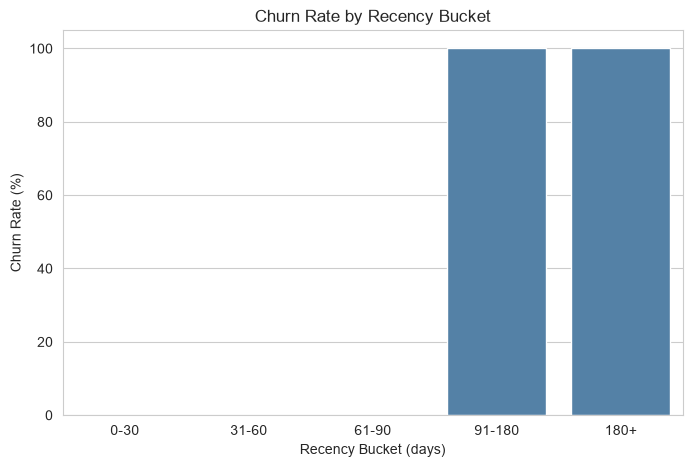

In [3]:
df['Recency_bucket'] = pd.cut(df['Recency'], bins=[0, 30, 60, 90, 180, 10000], 
                                labels=['0-30', '31-60', '61-90', '91-180', '180+'])

recency_churn = df.groupby('Recency_bucket', observed=True)['Churned'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=recency_churn.index, y=recency_churn.values, color='steelblue')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Recency Bucket (days)')
plt.title('Churn Rate by Recency Bucket')
plt.show()

4. Churn rate by Frequency buckets — zyada business-relevant insight (kyunki circular nahi hai):

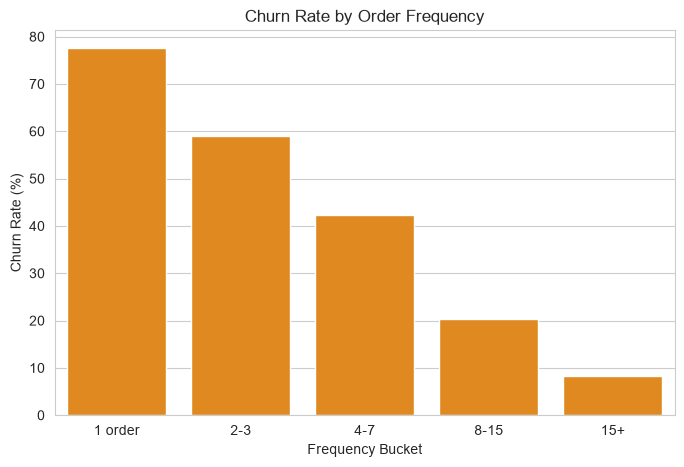

In [4]:
df['Frequency_bucket'] = pd.cut(df['Frequency'], bins=[0, 1, 3, 7, 15, 1000], 
                                  labels=['1 order', '2-3', '4-7', '8-15', '15+'])

freq_churn = df.groupby('Frequency_bucket', observed=True)['Churned'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=freq_churn.index, y=freq_churn.values, color='darkorange')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Frequency Bucket')
plt.title('Churn Rate by Order Frequency')
plt.show()

note: Yeh chart bahut important hai — agar yeh dikhata hai ki "jo customers sirf 1 order karte hain unka churn rate bahut zyada hai", to yeh ek actionable business insight hai (first-order customers ko retain karne ka plan banao).

5. Churn rate by Monetary buckets:

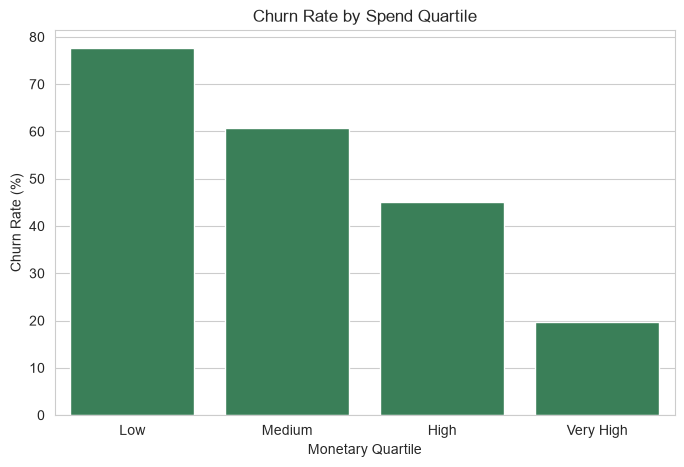

In [5]:
df['Monetary_bucket'] = pd.qcut(df['Monetary'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

monetary_churn = df.groupby('Monetary_bucket', observed=True)['Churned'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=monetary_churn.index, y=monetary_churn.values, color='seagreen')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Monetary Quartile')
plt.title('Churn Rate by Spend Quartile')
plt.show()

note: pd.qcut() (Day 13 ka NTILE concept yaad hai) data ko equal-sized groups mein baantta hai (quartiles), pd.cut() (upar Recency/Frequency mein use kiya) fixed boundaries se baantta hai — dono alag use-cases ke liye hain.

6. Churn rate by Customer_Segment (VIP vs Regular, Day 49):

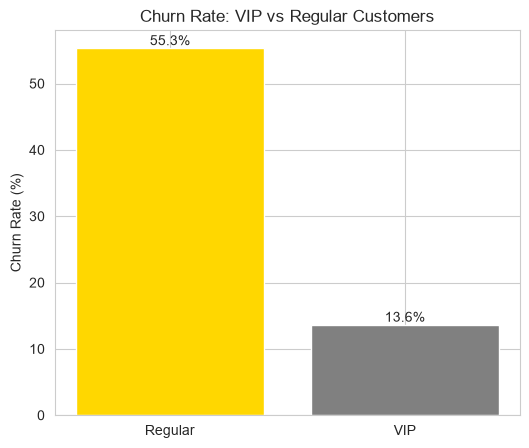

In [6]:
segment_churn = df.groupby('Customer_Segment')['Churned'].mean() * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(segment_churn.index, segment_churn.values, color=['gold', 'gray'])
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate: VIP vs Regular Customers')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center')
plt.show()

7. Combined dashboard — 4 churn-rate charts ek grid mein (Weekly Test 11 ka skill reuse karte hue):

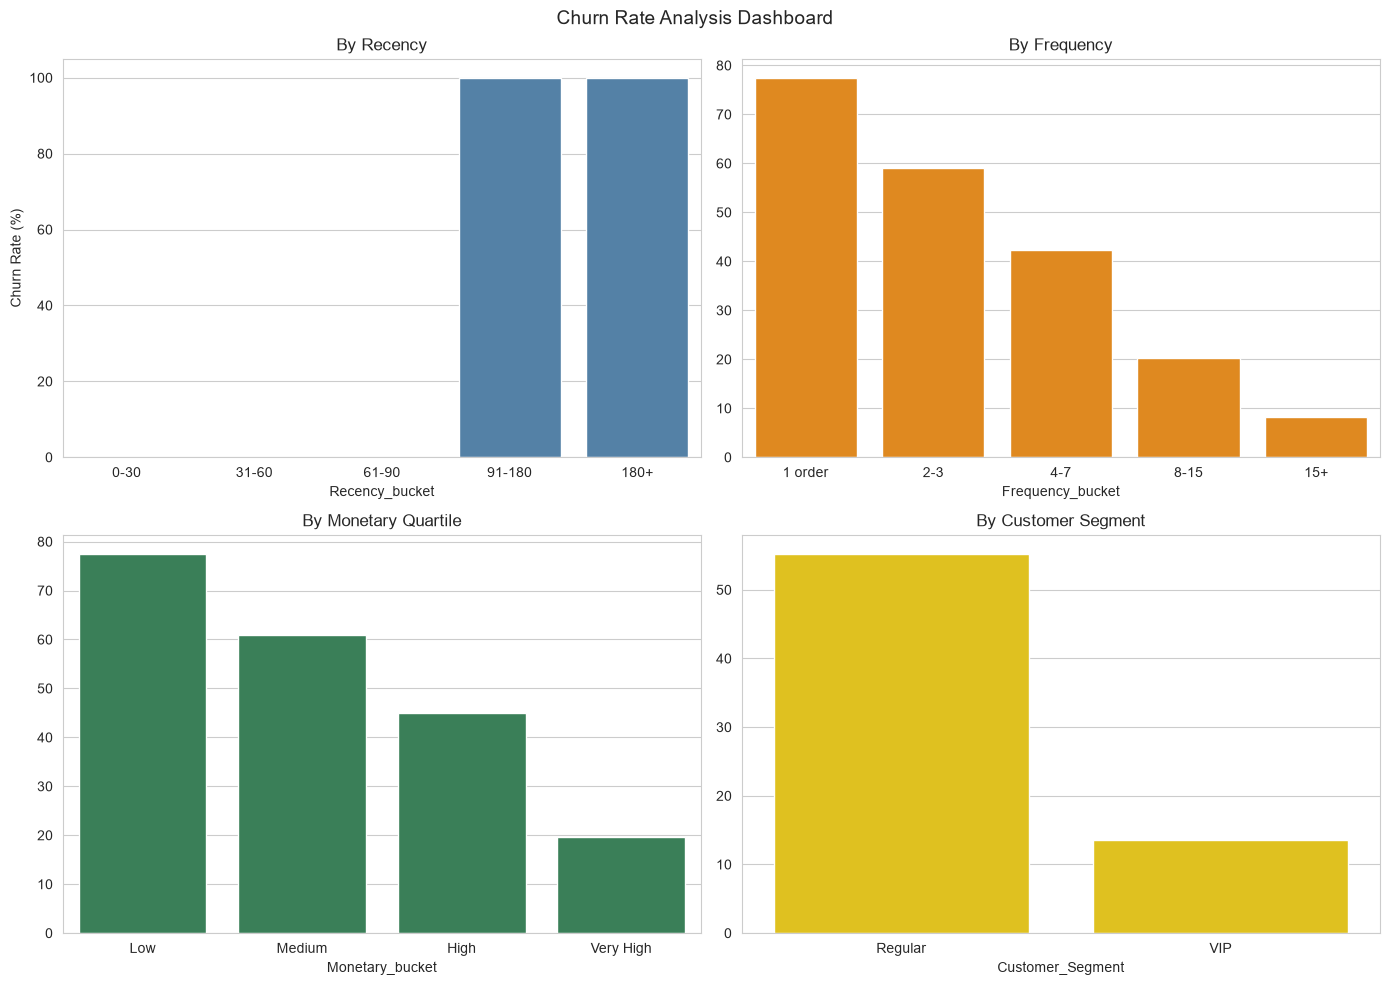

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x=recency_churn.index, y=recency_churn.values, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('By Recency')
axes[0,0].set_ylabel('Churn Rate (%)')

sns.barplot(x=freq_churn.index, y=freq_churn.values, color='darkorange', ax=axes[0,1])
axes[0,1].set_title('By Frequency')

sns.barplot(x=monetary_churn.index, y=monetary_churn.values, color='seagreen', ax=axes[1,0])
axes[1,0].set_title('By Monetary Quartile')

sns.barplot(x=segment_churn.index, y=segment_churn.values, color='gold', ax=axes[1,1])
axes[1,1].set_title('By Customer Segment')

plt.suptitle('Churn Rate Analysis Dashboard', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/churn_rate_dashboard.png', dpi=150)
plt.show()

practice questions:

1. Frequency_bucket wale chart se sabse high-risk bucket identify karo aur likho (comment mein) ki business is insight se kya action le sakta hai.

In [9]:
# High-Risk Segment: '1 order' (One-time buyers)
# Business Action: In customers ko identify karke ek targeted 'Welcome/Second-Purchase Campaign' 
# run karein (jaise ki next purchase par 10-15% discount ya personalized product recommendations), 
# taaki yeh one-time buyers repeat customers mein convert ho sakein.

2. Socho: Recency-based churn rate chart "circular" kyun hai (yaad karo Day 44/47 ka discussion), jabki Frequency/Monetary-based charts genuinely naye insights hain.

- Recency Chart Circular Kyon Hai?


    Churn ki definition hi aam taur par Recency par depend karti hai (jaise: jo customer pichle 90 ya 180 din se inactive hai, use 'Churned' mark kar diya jata hai). Jab aap Churn Rate ko Recency buckets ke sath plot karte hain, toh aap ek aisi cheez visualize kar rahe hain jo pehle se hi rule mein defined hai. Yeh ek tarah ka tautology (circular logic) ban jata hai—ziyada recency ka matlab hi automatic churn hai, isliye isse koi naya behavioral insight nahi milta.


- Frequency aur Monetary Charts Naye Insights Kyon Dete hain?


    Frequency aur Monetary metrics independent behavioral variables hain. Inhe churn label banane ke liye direct threshold ke roop mein use nahi kiya gaya hota. Isliye, jab aap inke charts dekhte hain, toh aapko asli business patterns pata chalte hain—jaise ki kya zyada kharch karne wale (Monetary = Very High) log bhi churn ho rahe hain, ya sirf low-frequency wale customers hi risk par hain.